Objective: perform data cleaning and manipulation, EDA using matplotlib and seaborn, improve customer experience by identifying potentiala customer across different state, occupation, gender and agegroup , improve sales by identifying most selling categories and product, which can help to plan inventory and hence meet the demands.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
df = pd.read_csv("Diwali.csv", encoding='ISO-8859-1')
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


In [3]:
df.shape

(11251, 15)

In [4]:
df.info

<bound method DataFrame.info of        User_ID    Cust_name Product_ID Gender Age Group  Age  Marital_Status  \
0      1002903    Sanskriti  P00125942      F     26-35   28               0   
1      1000732       Kartik  P00110942      F     26-35   35               1   
2      1001990        Bindu  P00118542      F     26-35   35               1   
3      1001425       Sudevi  P00237842      M      0-17   16               0   
4      1000588         Joni  P00057942      M     26-35   28               1   
...        ...          ...        ...    ...       ...  ...             ...   
11246  1000695      Manning  P00296942      M     18-25   19               1   
11247  1004089  Reichenbach  P00171342      M     26-35   33               0   
11248  1001209        Oshin  P00201342      F     36-45   40               0   
11249  1004023       Noonan  P00059442      M     36-45   37               0   
11250  1002744      Brumley  P00281742      F     18-25   19               0   

       

In [5]:
#drop unrelated blank columns
df.drop(['Status','unnamed1'],axis=1,inplace=True)

In [6]:
#Checking null values
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [7]:
#drop null values
df.dropna(inplace=True)
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0


In [8]:
df = df.dropna(subset=['Amount'])
df.loc[:, 'Amount'] = df['Amount'].astype(int)

In [9]:
df.describe()
#df[['Age','Orders','Amount']].describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [10]:
#EDA(Explorator Data Analysis)
#Gender

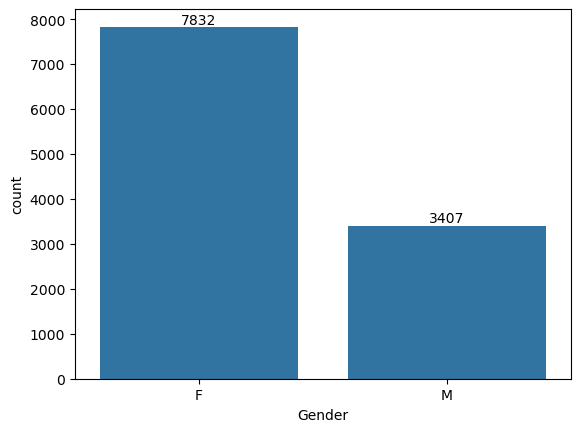

In [11]:
ax= sns.countplot(x='Gender',data=df)
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

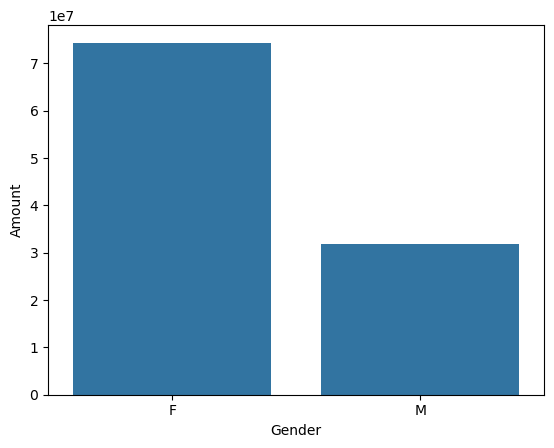

In [12]:
sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(x='Gender',y='Amount',data=sales_gen)

In [13]:

#df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)


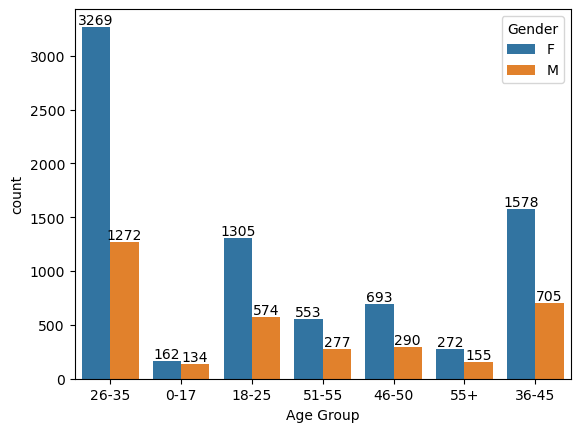

In [14]:
#Age
ax= sns.countplot(data=df,x='Age Group',hue='Gender')
for bars in ax.containers:
    ax.bar_label(bars)

In [15]:
#df.groupby(['Age'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

In [16]:
#Total ammount vs Age group
sales_age = df.groupby(['Age Group'],as_index = False)['Amount'].sum().sort_values(by='Amount',ascending=False)

<Axes: xlabel='Age Group', ylabel='Amount'>

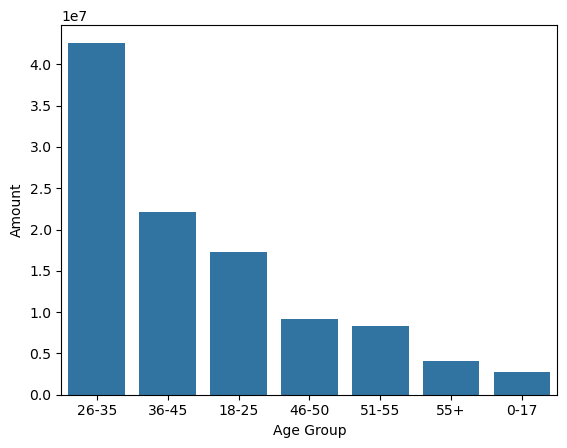

In [17]:
sns.barplot(x='Age Group',y='Amount',data=sales_age)

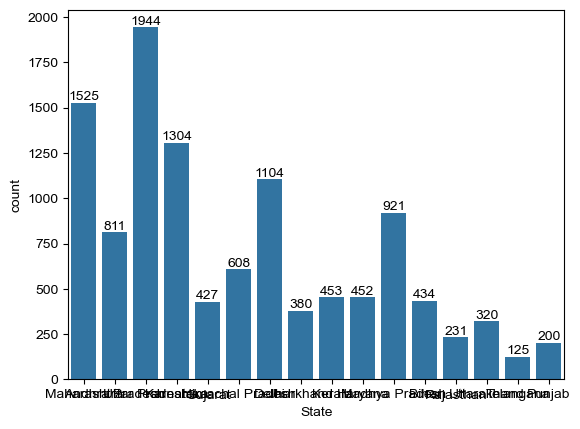

In [18]:
#state

ax= sns.countplot(x='State',data=df)
for bars in ax.containers:
    ax.bar_label(bars)
sns.set(rc={'figure.figsize':(25,15)})

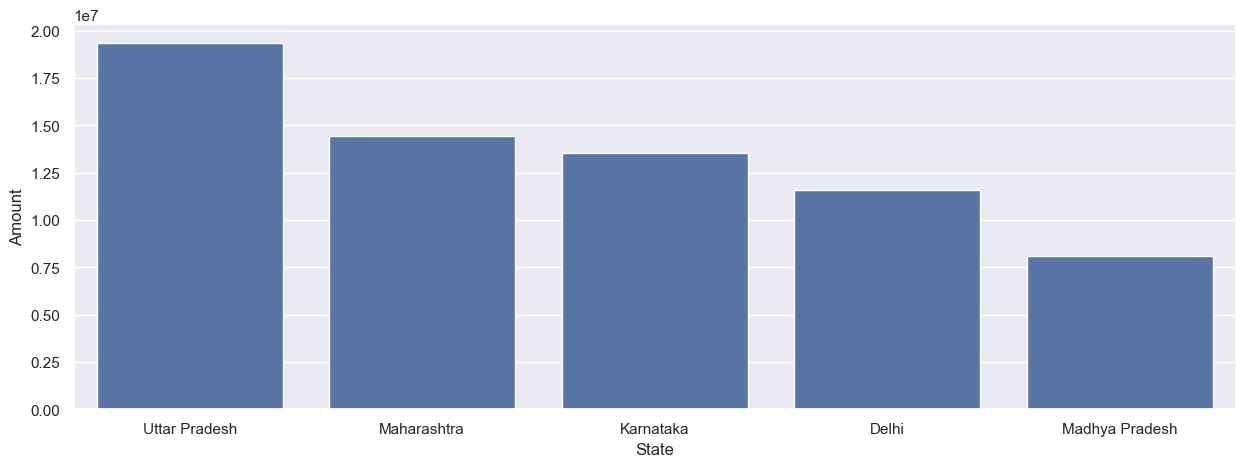

In [10]:
sales_state = df.groupby(['State'],as_index = False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(5)
sns.barplot(x='State',y='Amount',data=sales_state)
sns.set(rc={'figure.figsize':(25,15)})

In [20]:
print(df.columns)

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')


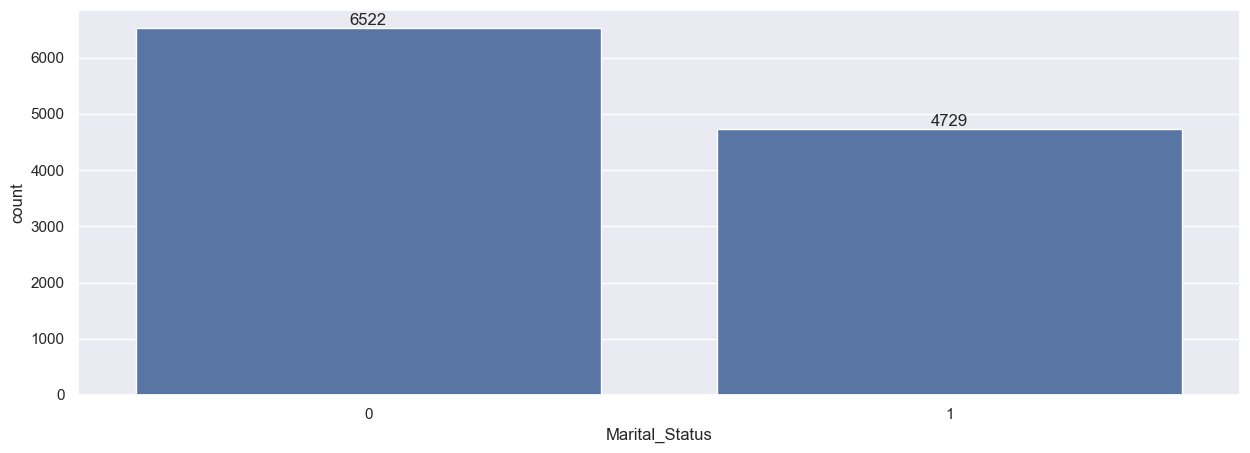

In [14]:
ax = sns.countplot(data=df, x= 'Marital_Status')
for bars in ax.containers:
    ax.bar_label(bars)
sns.set(rc={'figure.figsize':(5,5)})

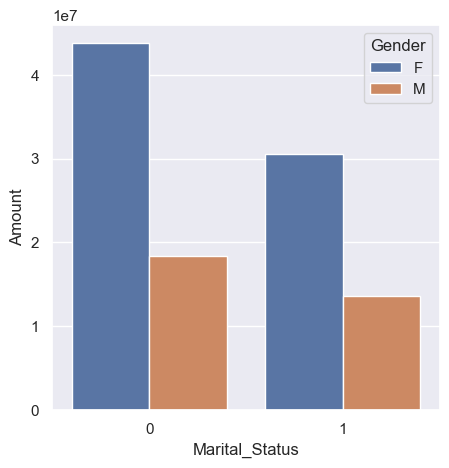

In [15]:
sales_martial_status = df.groupby(['Marital_Status','Gender'],as_index = False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(5)

sns.barplot(x='Marital_Status',y='Amount',data=sales_martial_status,hue='Gender')
sns.set(rc={'figure.figsize':(25,15)})

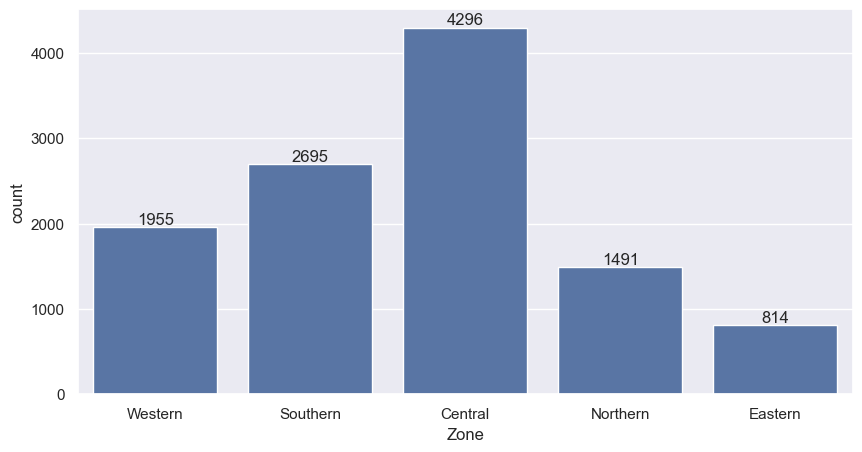

In [18]:
#Zone
ax= sns.countplot(x='Zone',data=df)
for bars in ax.containers:
    ax.bar_label(bars)
sns.set(rc={'figure.figsize':(5,5)})

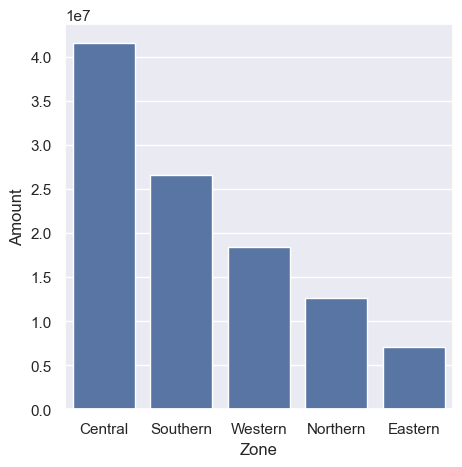

In [19]:
sales_zone = df.groupby(['Zone'],as_index = False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(5)
sns.barplot(x='Zone',y='Amount',data=sales_zone)
sns.set(rc={'figure.figsize':(5,5)})

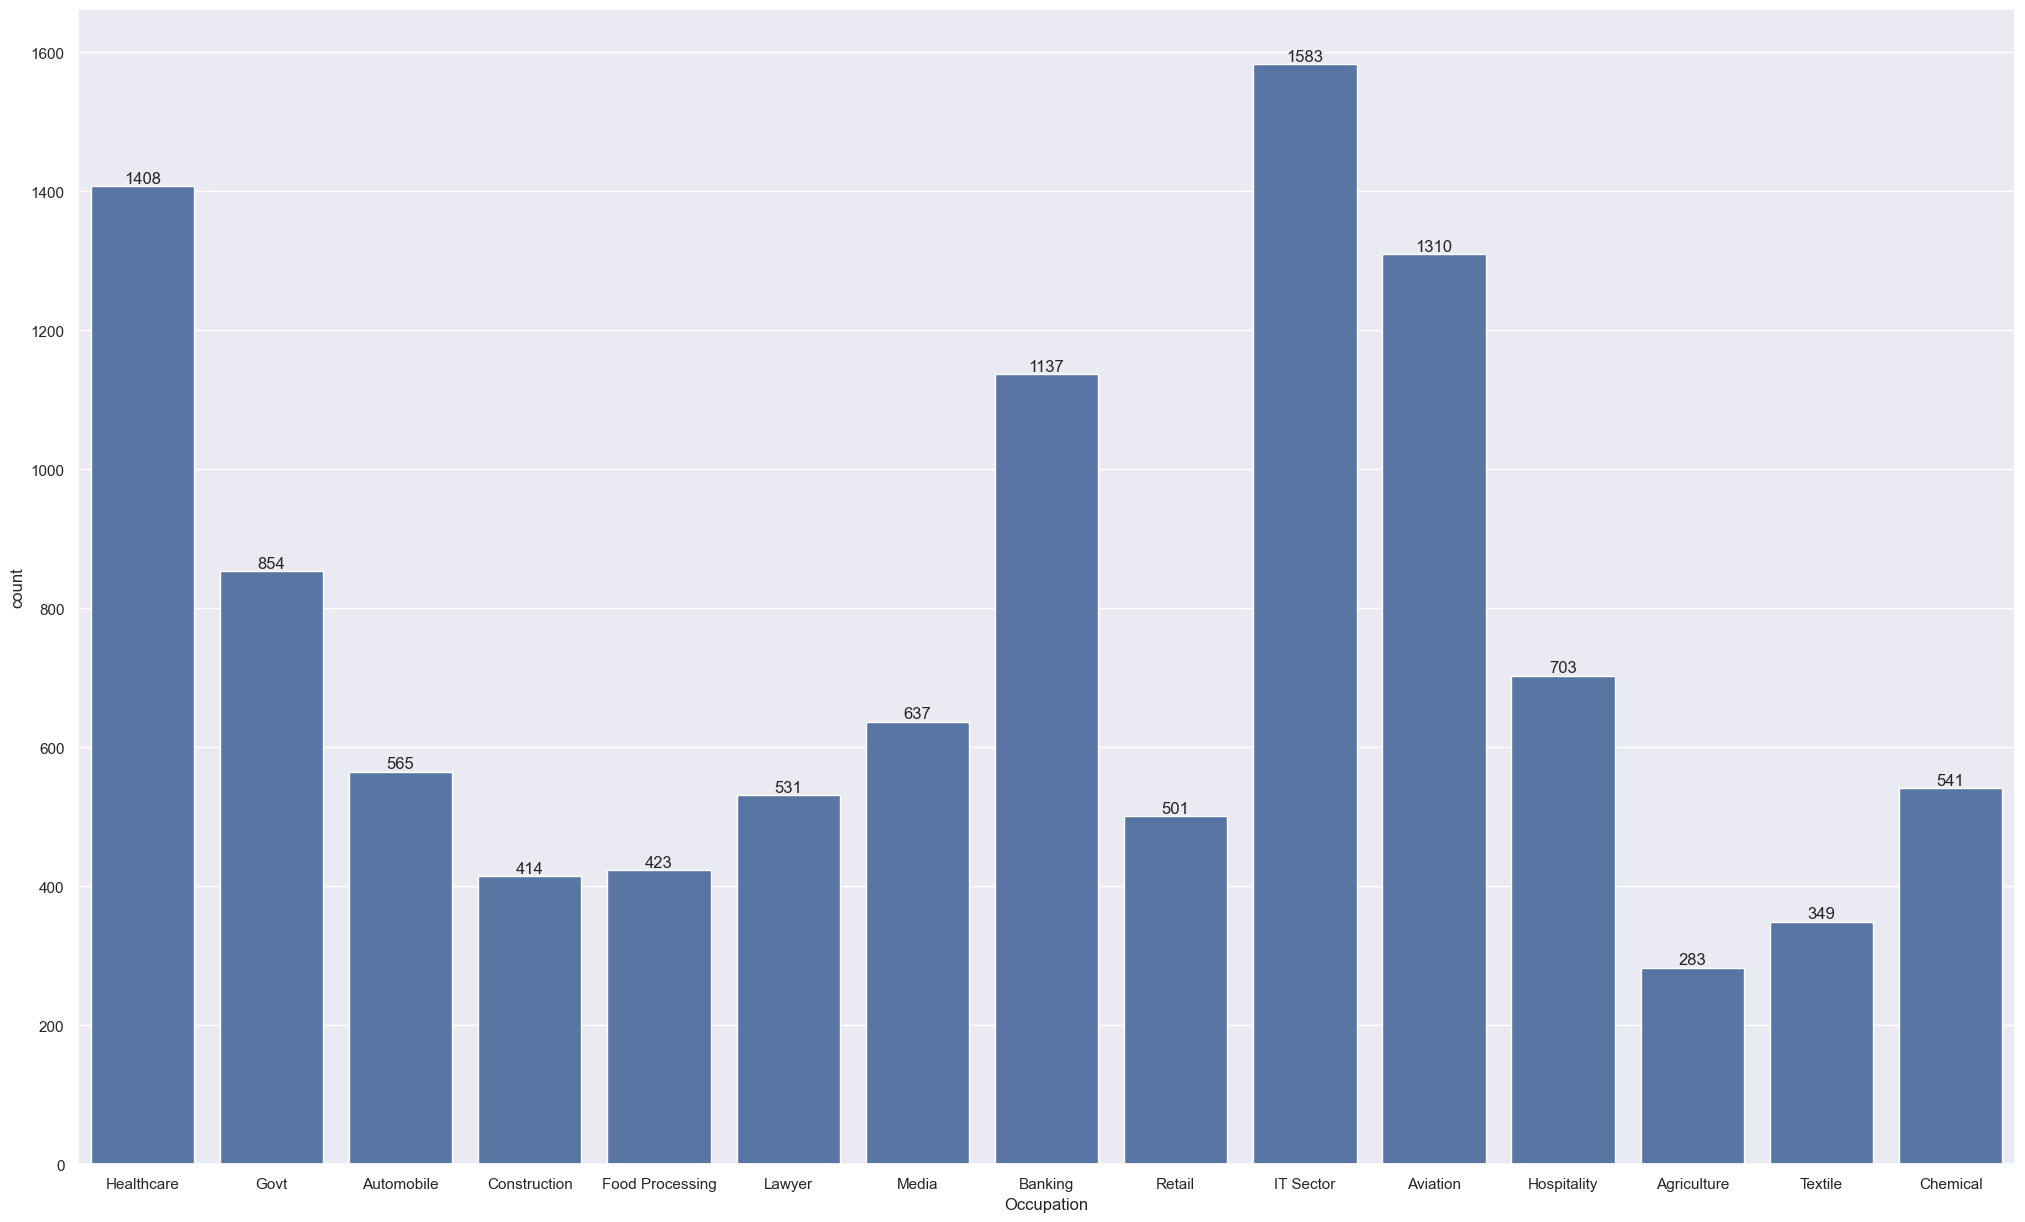

In [25]:
ax= sns.countplot(x='Occupation',data=df)
for bars in ax.containers:
    ax.bar_label(bars)
sns.set(rc={'figure.figsize':(25,15)})

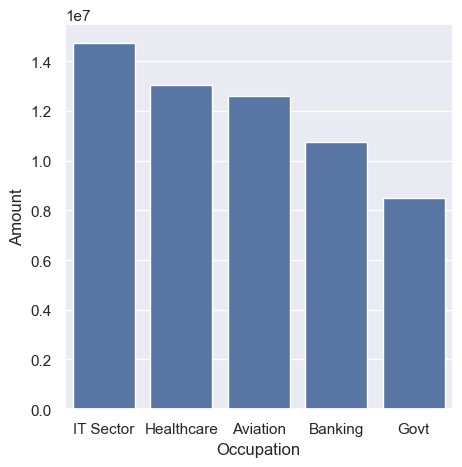

In [20]:
sales_occupation = df.groupby(['Occupation'],as_index = False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(5)
sns.barplot(x='Occupation',y='Amount',data=sales_occupation)
sns.set(rc={'figure.figsize':(25,15)})

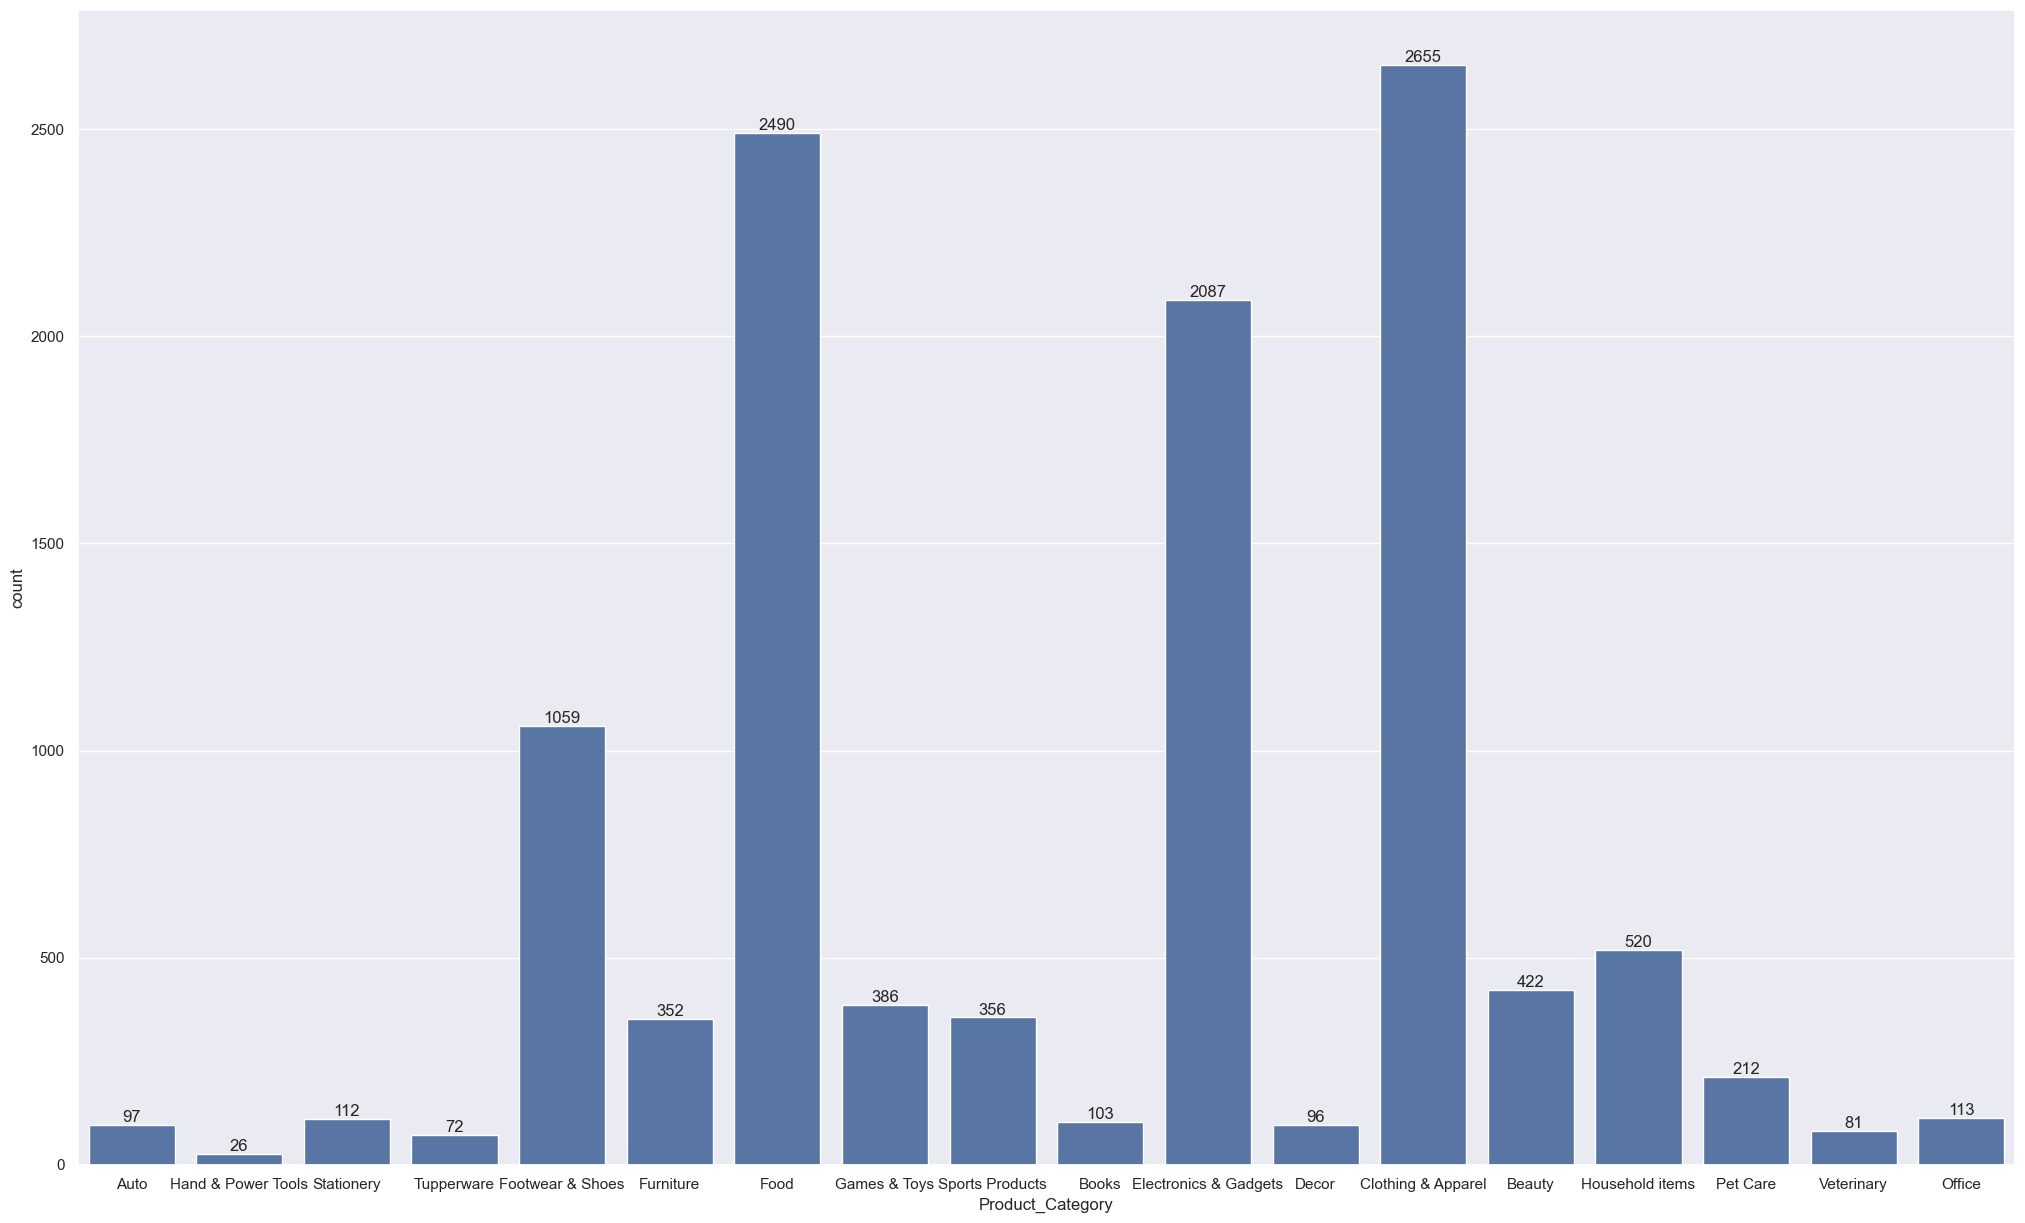

In [27]:
ax= sns.countplot(x='Product_Category',data=df)
for bars in ax.containers:
    ax.bar_label(bars)
sns.set(rc={'figure.figsize':(25,15)})

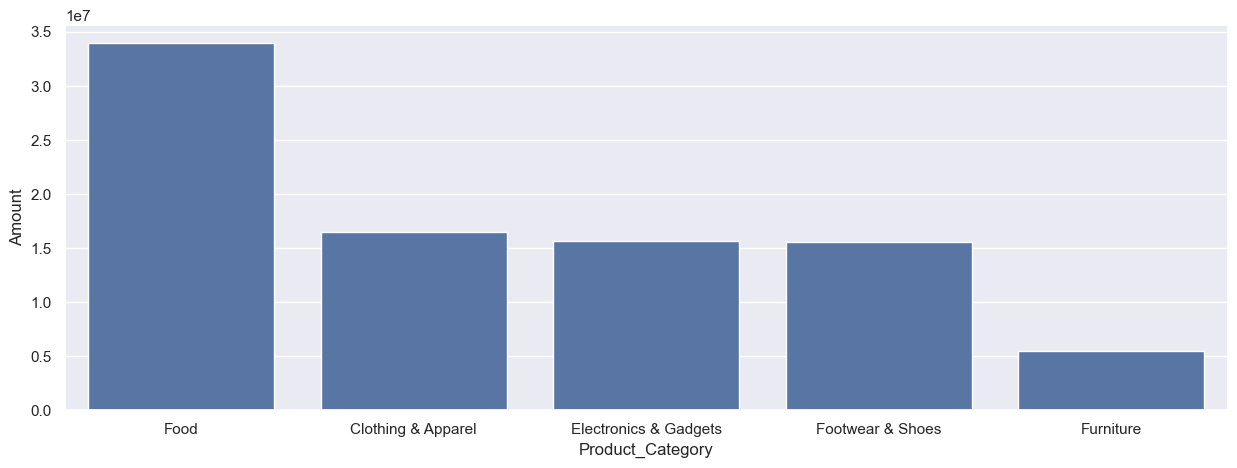

In [29]:
sales_product = df.groupby(['Product_Category'],as_index = False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(5)
sns.barplot(x='Product_Category',y='Amount',data=sales_product)
sns.set(rc={'figure.figsize':(15,25)})